In [57]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### V0

In [4]:
xl = pd.ExcelFile("Output/V0.xlsx")

print(f"Nombre de feuille : ",len(xl.sheet_names))
# une par ligne
for nom in xl.sheet_names:
    print(nom)

Nombre de feuille :  16
DATES_VISITE
df_V0
Feuil1
LEDD
PSYCHOTROPES
AUTRE_PARKINSON
CONSO_SPECIFIQUE
DIGITSMT_TRAILMT_DKEFS
PDQ39
LARS
HAMA
HAMD
MOCA
QUIP
ECMP
UPDRS


#### Feuille 1 

In [5]:
df_v0_dates_visite = pd.read_excel("Output/V0.xlsx", sheet_name="DATES_VISITE")
print(df_v0_dates_visite.shape)
df_v0_dates_visite.head()

(836, 2)


,SUBJID,D_SCREEN
0,Subject Identifier for the Study,date de la visite de screening
1,01-001,18/11/2013
2,01-002,13/01/2014
3,01-003,04/03/2014
4,01-004,12/05/2014


#### Feuille 2

In [6]:
df_v0 = pd.read_excel("Output/V0.xlsx", sheet_name="df_V0")
print(df_v0.shape)
df_v0.head()

(836, 7)


,SUBJID,INIT_PAT,TITRE,POIDS,POIDS_NR,TAILLE,TAILLE_NR
0,Subject Identifier for the Study,initiales patient,titre,poids,poids non réalisé,taille,taille non réalisé
1,01-001,SR,Visite de screening,76,NaN,171,NaN
2,01-002,TM,Visite de screening,88,NaN,180,NaN
3,01-003,SJ,Visite de screening,89,NaN,176,NaN
4,01-004,DJ,Visite de screening,59,NaN,163,NaN


In [ ]:
df_v0.drop(columns=["POIDS_NR", "TAILLE_NR","TITRE"], inplace=True)

In [16]:
df_V0 = pd.merge(df_v0_dates_visite,df_v0,on="SUBJID",how="left" )

#### Feuille 1 + 2   *

In [38]:
df_V0.insert(0, "VISITE", 0)

In [39]:
df_V0

,VISITE,SUBJID,D_SCREEN,INIT_PAT,POIDS,TAILLE
0,0,Subject Identifier for the Study,date de la visite de screening,initiales patient,poids,taille
1,0,01-001,18/11/2013,SR,76,171
2,0,01-002,13/01/2014,TM,88,180
3,0,01-003,04/03/2014,SJ,89,176
4,0,01-004,12/05/2014,DJ,59,163
...,...,...,...,...,...,...
831,0,20-025,21/06/2018,DA,74,172
832,0,20-026,04/07/2018,ME,98,187
833,0,20-027,12/07/2018,RP,78,178
834,0,20-028,08/11/2018,DN,85,160


#### Feuille 3 *

In [21]:
df_v0_Feuil1 = pd.read_excel("Output/V0.xlsx", sheet_name="Feuil1")
print(df_v0_Feuil1.shape)
df_v0_Feuil1.head()

(794, 7)


,Subject Identifier for the Study,Num,ledd_levot,ledd_agot,ledd_imaobt,ledd_mantt,ledd_tot
0,01-001,1,731.50,240.0,NaN,400.0,1371.50
1,01-002,1,1729.00,480.0,100.0,NaN,2309.00
2,01-003,1,1795.50,NaN,100.0,NaN,1895.50
3,01-004,1,1150.00,480.0,NaN,NaN,1630.00
4,01-005,1,1828.75,NaN,NaN,NaN,1828.75


In [35]:
df_v0_Feuil1.rename(columns={"Subject Identifier for the Study": "SUBJID"}, inplace=True)

In [36]:
df_v0_LEED = df_v0_Feuil1

In [42]:
df_v0_LEED.drop("Num",axis=1,inplace=True)

In [40]:
df_v0_LEED.insert(0, "VISITE", 0)

In [62]:
df_v0_LEED.head()

,VISITE,SUBJID,ledd_levot,ledd_agot,ledd_imaobt,ledd_mantt,ledd_tot
0,0,01-001,731.50,240.0,NaN,400.0,1371.50
1,0,01-002,1729.00,480.0,100.0,NaN,2309.00
2,0,01-003,1795.50,NaN,100.0,NaN,1895.50
3,0,01-004,1150.00,480.0,NaN,NaN,1630.00
4,0,01-005,1828.75,NaN,NaN,NaN,1828.75


In [49]:
df_v0_LEED.describe()

,VISITE,ledd_levot,ledd_agot,ledd_imaobt,ledd_mantt,ledd_tot
count,794.0,778.000000,596.000000,343.00000,224.000000,790.000000
mean,0.0,1028.736558,451.966904,238.19242,158.308036,1502.392806
std,0.0,631.179679,1035.136271,1144.40500,103.065997,1290.593837
min,0.0,5.320000,0.000000,50.00000,0.000000,65.320000
25%,0.0,665.000000,160.000000,100.00000,100.000000,991.450500
50%,0.0,961.875950,299.880000,100.00000,200.000000,1338.750000
75%,0.0,1263.500000,442.098000,100.00000,200.000000,1722.062500
max,0.0,10000.000000,16475.000000,10000.00000,400.000000,17738.750000


In [51]:
df_v0_LEED.isna().sum()/df_v0_LEED.shape[0]

VISITE         0.000000
SUBJID         0.000000
ledd_levot     0.020151
ledd_agot      0.249370
ledd_imaobt    0.568010
ledd_mantt     0.717884
ledd_tot       0.005038
dtype: float64

In [55]:
df_v0_LEED[df_v0_LEED["ledd_tot"].isna()]

,VISITE,SUBJID,ledd_levot,ledd_agot,ledd_imaobt,ledd_mantt,ledd_tot
495,0,11-008,NaN,NaN,NaN,NaN,NaN
607,0,15-021,NaN,NaN,NaN,NaN,NaN
752,0,19-034,NaN,NaN,NaN,NaN,NaN
754,0,19-036,NaN,NaN,NaN,NaN,NaN


#### Feuille 4 

In [ ]:
df_v0_LEED = pd.read_excel("Output/V0.xlsx", sheet_name="LEDD")
print(df_v0_LEED.shape)
df_v0_LEED.head()

(794, 37)


,v,Subject Identifier for the Study,Visit,Num,médicament 1,posologie 1,médicament 2,posologie 2,médicament 3,posologie 3,...,posologie 12,médicament 13,posologie 13,ledd_levo,fact_icomt,ledd_levot,ledd_agot,ledd_imaobt,ledd_mantt,ledd_tot
0,1,01-001,Traitements concomittants antiparkinsoniens sp...,1,NaN,200 MG LDOPA,MODOPAR 125 LP,100 MG L DOPA,STALEVO 75 MG,5X75= 250 MG L DOPA,...,NaN,NaN,NaN,550.0,1.33,731.50,240.0,NaN,400.0,1371.50
1,1,01-002,Traitements concomittants antiparkinsoniens sp...,1,REQUIP,LP 24 MG 1 PAR JOUR,AZILECT,1 MG LE MATIN,MODOPAR,125 MG LP 2 AU COUCHER,...,NaN,NaN,NaN,1300.0,1.33,1729.00,480.0,100.0,NaN,2309.00
2,1,01-003,Traitements concomittants antiparkinsoniens sp...,1,STALEVO 200,4 / JOUR,STALEVO 150,3 / JOUR,AZILECT,1MG,...,NaN,NaN,NaN,1350.0,1.33,1795.50,NaN,100.0,NaN,1895.50
3,1,01-004,Traitements concomittants antiparkinsoniens sp...,1,MODOPAR 125 DISPERSIBLE,3 CP LE MATIN,MODOPAR 125 GELULES,7 PAR JOUR,SINEMET LP 100,2 LE SOIR,...,NaN,NaN,NaN,1150.0,1.00,1150.00,480.0,NaN,NaN,1630.00
4,1,01-005,Traitements concomittants antiparkinsoniens sp...,1,MODOPAR,125 * 2 PAR JOUR,MODOPAR DISPERSIBLE,125 * 1 PAR JOUR,SINEMET LP,100 * 1 PAR JOUR,...,NaN,NaN,NaN,1375.0,1.33,1828.75,NaN,NaN,NaN,1828.75


In [32]:
df_v0_LEED_info = df_v0_LEED.iloc[:,:-7]

In [33]:
df_v0_LEED_info.drop("v",axis=1,inplace=True)

In [34]:
df_v0_LEED_info.rename(columns={"Subject Identifier for the Study": "SUBJID"}, inplace=True)

In [45]:
df_v0_LEED_info.insert(0, "VISITE", 0)

In [47]:
df_v0_LEED_info.drop("Num",axis=1,inplace=True)

In [48]:
df_v0_LEED_info

,VISITE,SUBJID,Visit,médicament 1,posologie 1,médicament 2,posologie 2,médicament 3,posologie 3,médicament 4,...,médicament 9,posologie 9,médicament 10,posologie 10,méicament 11,posologie 11,médicament 12,posologie 12,médicament 13,posologie 13
0,0,01-001,Traitements concomittants antiparkinsoniens sp...,NaN,200 MG LDOPA,MODOPAR 125 LP,100 MG L DOPA,STALEVO 75 MG,5X75= 250 MG L DOPA,STALEVO 50 MG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,01-002,Traitements concomittants antiparkinsoniens sp...,REQUIP,LP 24 MG 1 PAR JOUR,AZILECT,1 MG LE MATIN,MODOPAR,125 MG LP 2 AU COUCHER,MODOPAR 125 DISPERSIBLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,01-003,Traitements concomittants antiparkinsoniens sp...,STALEVO 200,4 / JOUR,STALEVO 150,3 / JOUR,AZILECT,1MG,MODOPAR DISPERSIBLE 125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,01-004,Traitements concomittants antiparkinsoniens sp...,MODOPAR 125 DISPERSIBLE,3 CP LE MATIN,MODOPAR 125 GELULES,7 PAR JOUR,SINEMET LP 100,2 LE SOIR,NEUPRO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,01-005,Traitements concomittants antiparkinsoniens sp...,MODOPAR,125 * 2 PAR JOUR,MODOPAR DISPERSIBLE,125 * 1 PAR JOUR,SINEMET LP,100 * 1 PAR JOUR,STALEVO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,0,20-025,Traitements concomittants antiparkinsoniens sp...,AZILECT,1 MG,REQUIP LP,16 MG,STALEVO,775 MG,MODOPAR DISPERSIBLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
790,0,20-026,Traitements concomittants antiparkinsoniens sp...,AZILECT,1 MG,STALEVO,800 MG,SINEMET LP,200 MG,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
791,0,20-027,Traitements concomittants antiparkinsoniens sp...,MODOPAR,2375 MG,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
792,0,20-028,Traitements concomittants antiparkinsoniens sp...,MODOPAR,1000MG,MODOPAR LP,250MG,COMTAN,700MG,NEUPRO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Feuille 5 

In [56]:
df_v0_PSYCHOTROPES = pd.read_excel("Output/V0.xlsx", sheet_name="PSYCHOTROPES")
print(df_v0_PSYCHOTROPES.shape)
df_v0_PSYCHOTROPES.head()

(835, 83)


,SUBJID,VISIT,NUM,Unnamed: 3,INIT_PAT,MEDICMT1,D_DEB1,POSO1,INDIC1,D_FIN1,...,POSO12,INDIC12,D_FIN12,ENCOURS12,MEDICMT13,D_DEB13,POSO13,INDIC13,D_FIN13,ENCOURS13
0,01-001,Les traitements psychotropes,1,V0,SR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-002,Les traitements psychotropes,1,NaN,TM,NOCTAMINE,NaN,1 MG,INSOMNIE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-003,Les traitements psychotropes,1,NaN,SJ,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-004,Les traitements psychotropes,1,NaN,DJ,CYMBALTA,NaN,60 MG,ANTIDEPRESSEUR,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-005,Les traitements psychotropes,1,NaN,LB,PAROXETINE,NaN,1 MG,ANXIETE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

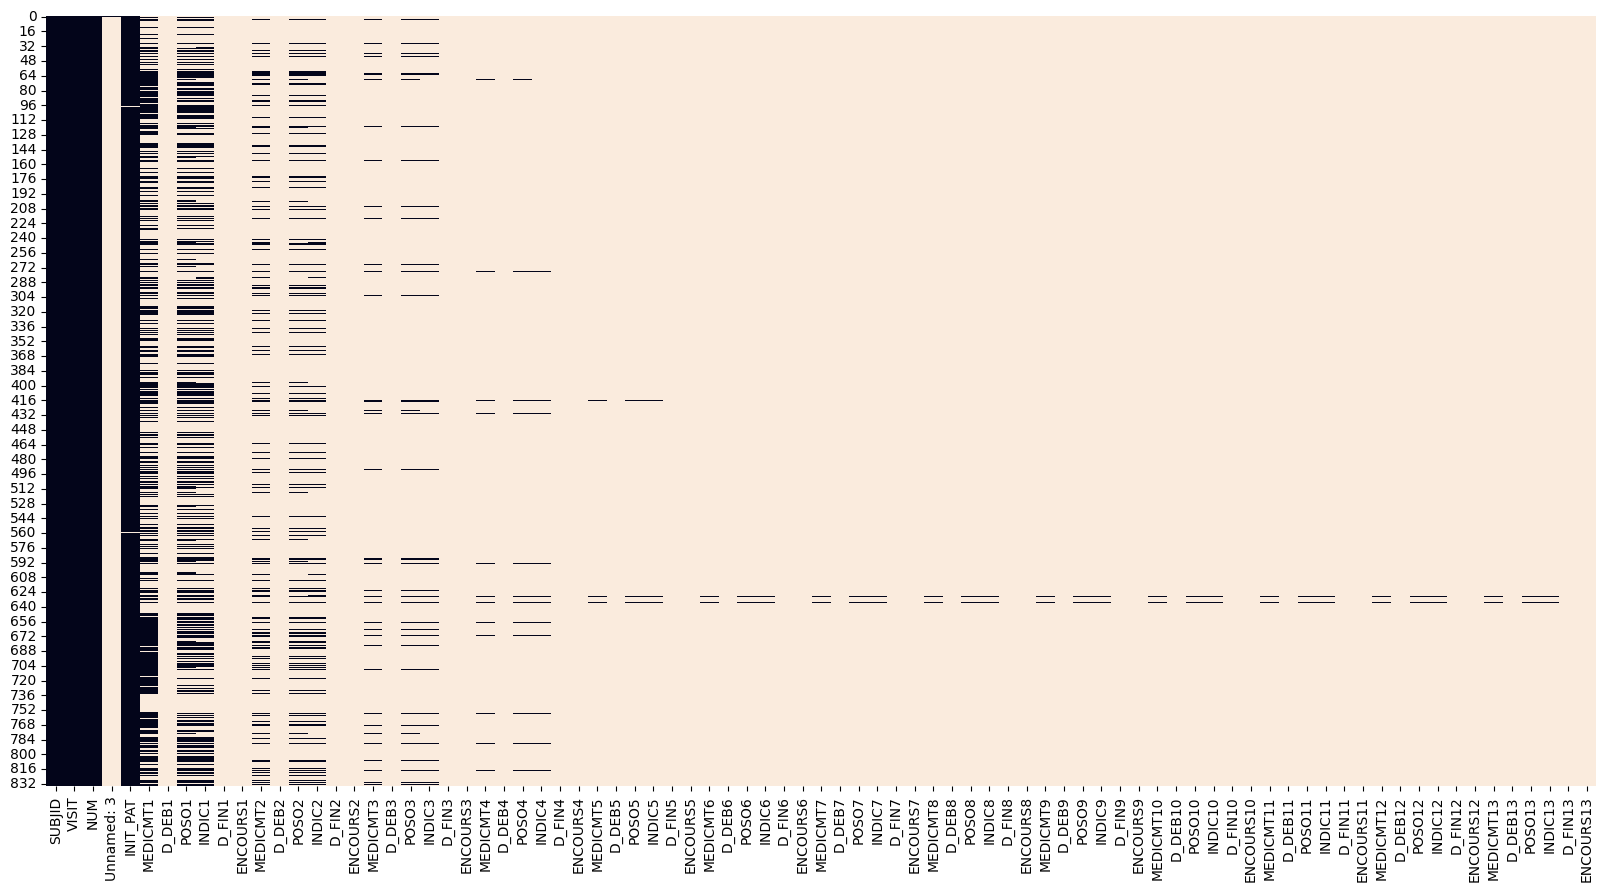

In [58]:
plt.figure(figsize=(20,10))
sns.heatmap(df_v0_PSYCHOTROPES.isna(),cbar=False)  

In [59]:
df_v0_PSYCHOTROPES.insert(0, "VISITE", 0)
df_v0_PSYCHOTROPES.drop(columns=["NUM","Unnamed: 3"],inplace=True)

In [61]:
df_v0_PSYCHOTROPES.head()

,VISITE,SUBJID,VISIT,INIT_PAT,MEDICMT1,D_DEB1,POSO1,INDIC1,D_FIN1,ENCOURS1,...,POSO12,INDIC12,D_FIN12,ENCOURS12,MEDICMT13,D_DEB13,POSO13,INDIC13,D_FIN13,ENCOURS13
0,0,01-001,Les traitements psychotropes,SR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,01-002,Les traitements psychotropes,TM,NOCTAMINE,NaN,1 MG,INSOMNIE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,01-003,Les traitements psychotropes,SJ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,01-004,Les traitements psychotropes,DJ,CYMBALTA,NaN,60 MG,ANTIDEPRESSEUR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,01-005,Les traitements psychotropes,LB,PAROXETINE,NaN,1 MG,ANXIETE,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Feuille 6 

In [63]:
df_v0_AUTRE_PARKINSON = pd.read_excel("Output/V0.xlsx", sheet_name="AUTRE_PARKINSON")
print(df_v0_AUTRE_PARKINSON.shape)
df_v0_AUTRE_PARKINSON.head()

(835, 83)


,SUBJID,VISIT,NUM,Unnamed: 3,INIT_PAT,MEDICMT1,D_DEB1,POSO1,INDIC1,D_FIN1,...,POSO12,INDIC12,D_FIN12,ENCOURS12,MEDICMT13,D_DEB13,POSO13,INDIC13,D_FIN13,ENCOURS13
0,01-001,Autres médicaments prescrits dans le cadre de ...,1,V0,SR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-002,Autres médicaments prescrits dans le cadre de ...,1,NaN,TM,APOKINON,NaN,NaN,4 MG 4 PAR JOUR SI BLOCAGE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-003,Autres médicaments prescrits dans le cadre de ...,1,NaN,SJ,HEPTAMYL,NaN,.K,"187,8X3/JOUR",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-004,Autres médicaments prescrits dans le cadre de ...,1,NaN,DJ,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-005,Autres médicaments prescrits dans le cadre de ...,1,NaN,LB,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

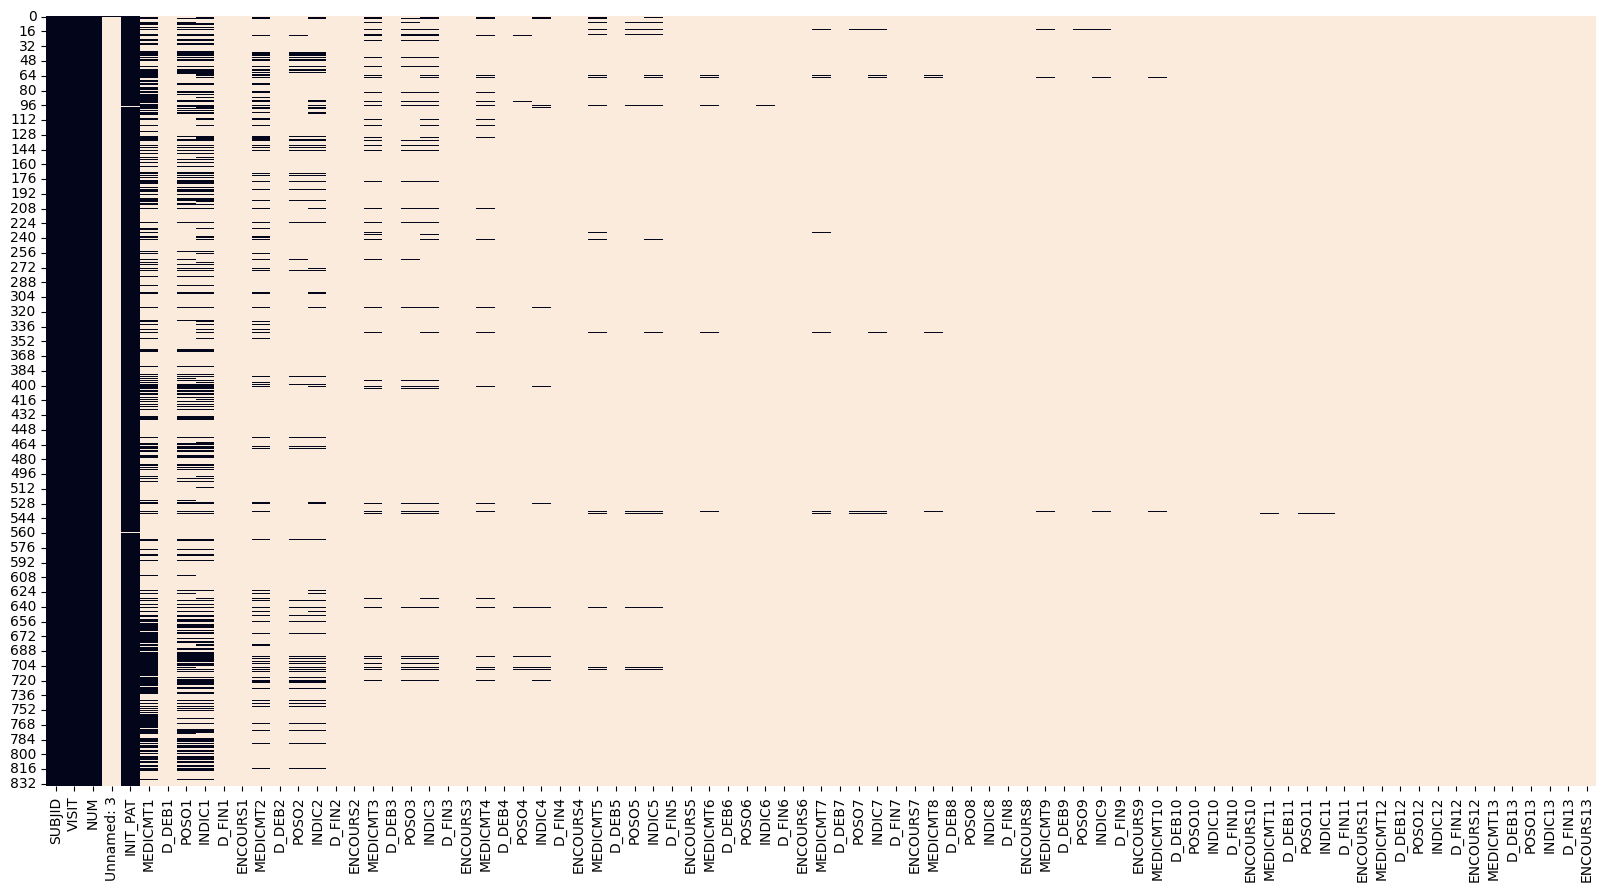

In [64]:
plt.figure(figsize=(20,10))
sns.heatmap(df_v0_AUTRE_PARKINSON.isna(),cbar=False)  

In [65]:
df_v0_AUTRE_PARKINSON.insert(0, "VISITE", 0)
df_v0_AUTRE_PARKINSON.drop(columns=["NUM","Unnamed: 3"],inplace=True)

#### Feuille 7

In [ ]:
df_v0_CONSO_SPECIFIQUE = pd.read_excel("Output/V0.xlsx", sheet_name="CONSO_SPECIFIQUE")
print(df_v0_CONSO_SPECIFIQUE.shape)
df_v0_CONSO_SPECIFIQUE.head()

(835, 113)


,SUBJID,VISIT,NUM,VISIT_NOM,NUM_CENTRE,NUM_PAT,INIT_PAT,MEDICMT1,POSO1,CAT_TRT_ANTIPARK1,...,CONCAT_4,CONCAT_5,CONCAT_6,CONCAT_7,CONCAT_8,CONCAT_9,CONCAT_10,CONCAT_11,CONCAT_12,CONCAT_13
0,01-001,Traitements concomittants antiparkinsoniens sp...,1,Screening,1.0,1.0,SR,NaN,200 MG LDOPA,NaN,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-002,Traitements concomittants antiparkinsoniens sp...,1,Screening,1.0,2.0,TM,REQUIP,LP 24 MG 1 PAR JOUR,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-003,Traitements concomittants antiparkinsoniens sp...,1,Screening,1.0,3.0,SJ,STALEVO 200,4 / JOUR,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-004,Traitements concomittants antiparkinsoniens sp...,1,Screening,1.0,4.0,DJ,MODOPAR 125 DISPERSIBLE,3 CP LE MATIN,1.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-005,Traitements concomittants antiparkinsoniens sp...,1,Screening,1.0,5.0,LB,MODOPAR,125 * 2 PAR JOUR,1.0,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
df_v0_CONSO_SPECIFIQUE.insert(0, "VISITE", 0)
df_v0_CONSO_SPECIFIQUE.drop(columns=["NUM","VISIT_NOM","NUM_CENTRE","NUM_PAT","INIT_PAT"],inplace=True)

#### Feuille 8

In [68]:
df_v0_DIGITSMT_TRAILMT_DKEFS = pd.read_excel("Output/V0.xlsx", sheet_name="DIGITSMT_TRAILMT_DKEFS")
print(df_v0_DIGITSMT_TRAILMT_DKEFS.shape)
df_v0_DIGITSMT_TRAILMT_DKEFS.head()

(835, 22)


,SUBJID,INIT_PAT,TITRE,DIGITSMT_NBSUBSTI,DIGITSMT_NBCORRECT,TRAILMT_ALPHABET,TRAILMT_CHIFFRE,TRAILMT_LETTRECHIFFRE,TRAILMT_NB_ERREURS,DKEFS_TPS1,...,DKEFS_TPS2,DKEFS_NBERR2,DKEFS_AUTOCORR2,DKEFS_TPS3,DKEFS_NBERR3,DKEFS_AUTOCORR3,DKEFS_TPS4,DKEFS_NBERR4,DKEFS_AUTOCORR4,BENTON_NBCORR
0,01-001,SR,Visite de screening,38,37,.D,.D,.D,.D,.D,...,.D,.D,.D,.D,.D,.D,.D,.D,.D,10
1,01-002,TM,Visite de screening,50,28,.D,.D,.D,.D,.D,...,.D,.D,.D,.D,.D,.D,.D,.D,.D,13
2,01-003,SJ,Visite de screening,28,20,.D,.D,.D,.D,.D,...,.D,.D,.D,.D,.D,.D,.D,.D,.D,12
3,01-004,DJ,Visite de screening,50,49,.D,.D,.D,.D,.D,...,.D,.D,.D,.D,.D,.D,.D,.D,.D,12
4,01-005,LB,Visite de screening,42,0,.D,.D,.D,.D,.D,...,.D,.D,.D,54,3,3,.D,.D,.D,11


In [71]:
df_v0_DIGITSMT_TRAILMT_DKEFS[
    df_v0_DIGITSMT_TRAILMT_DKEFS["TRAILMT_ALPHABET"].str.startswith(".", na=False)
]["TRAILMT_ALPHABET"].value_counts()



TRAILMT_ALPHABET
.D    52
.A    19
.K     5
.F     2
Name: count, dtype: int64

In [72]:
df_v0_DIGITSMT_TRAILMT_DKEFS.insert(0, "VISITE", 0)
df_v0_DIGITSMT_TRAILMT_DKEFS.drop(columns=["TITRE","INIT_PAT"],inplace=True)

#### Feuille 9

## EXCEL 

### V0

In [ ]:
df_

In [75]:
import pandas as pd

# ============================================================
#   DOSSIER DE SORTIE  (change si besoin)
# ============================================================
OUTPUT_DIR = "Output2"   


# ============================================================
#   GROUPE 1 : fichier V0.xlsx
# ============================================================
sheets_V0 = {
    "df_V0"                 : df_v0,
    "LEED_info"                       : df_v0_LEED_info,
    "LEED"                         : df_v0_LEED,
    "PSYCHOTROPES"                 : df_v0_PSYCHOTROPES,
    "AUTRE_PARKINSON"              : df_v0_AUTRE_PARKINSON,
    "CONSO_SPECIFIQUE"             : df_v0_CONSO_SPECIFIQUE,
    "DIGITSMT_TRAILMT_DKEFS"       : df_v0_DIGITSMT_TRAILMT_DKEFS,

    
}

# # ============================================================
# #   GROUPE 2 : fichier v1.xlsx
# # ============================================================
# sheets_v1 = {
#     "DATES_VISITE"                 : df_v1_DATES_VISITE,
#     "df_v1"                        : df_v1,
#     "Feuil1"                       : df_v1_Feuil1,
#     "LEDD"                         : df_v1_LEDD,
#     "PSYCHOTROPES"                 : df_v1_PSYCHOTROPES,
#     "AUTRE_PARKINSON"              : df_v1_AUTRE_PARKINSON,
#     "FREQUENCE"                    : df_v1_FREQUENCE,
#     "CONSO_SPECIFIQUE"             : df_v1_CONSO_SPECIFIQUE,
#     "DIGITSMT_TRAILMT_DKEFS"       : df_v1_DIGITSMT_TRAILMT_DKEFS,
#     "PDQ39"                        : df_v1_PDQ39,
#     "LARS"                         : df_v1_LARS,
#     "HAMA"                         : df_v1_HAMA,
#     "HAMD"                         : df_v1_HAMD,
#     "MOCA"                         : df_v1_MOCA,
#     "QUIP"                         : df_v1_QUIP,
#     "ECMP"                         : df_v1_ECMP,
#     "UPDRS"                        : df_v1_UPDRS,
#     "Poids_Taille"                 : df_v1_Poids_Taille,
# }

# # ============================================================
# #   GROUPE 3 : fichier vc.xlsx
# # ============================================================
# sheets_vc = {
#     "DATES_VISITE"                 : df_vc_DATES_VISITE,
#     "CONSO_SPECIFIQUE"             : df_vc_CONSO_SPECIFIQUE,
#     "Feuil1"                       : df_vc_Feuil1,
#     "LEDD"                         : df_vc_LEDD,
#     "PSYCHOTROPES"                 : df_vc_PSYCHOTROPES,
#     "AUTRE_PARKINSON"              : df_vc_AUTRE_PARKINSON,
#     "CONSO_SPECIFIQUE"             : df_vc_CONSO_SPECIFIQUE,
# }

# # ============================================================
# #   GROUPE 4 : fichier v3.xlsx
# # ============================================================
# sheets_v3 = {
#     "DATES_VISITE"                 : df_v3_DATES_VISITE,
#     "df_v3"                        : df_v3,
#     "Feuil1"                       : df_v3_Feuil1,
#     "LEDD"                         : df_v3_LEDD,
#     "PSYCHOTROPES"                 : df_v3_PSYCHOTROPES,
#     "AUTRE_PARKINSON"              : df_v3_AUTRE_PARKINSON,
#     "FREQUENCE"                    : df_v3_FREQUENCE,
#     "CONSO_SPECIFIQUE"             : df_v3_CONSO_SPECIFIQUE,
#     "DIGITSMT_TRAILMT_DKEFS"       : df_v3_DIGITSMT_TRAILMT_DKEFS,
#     "PDQ39"                        : df_v3_PDQ39,
#     "LARS"                         : df_v3_LARS,
#     "HAMA"                         : df_v3_HAMA,
#     "HAMD"                         : df_v3_HAMD,
#     "MOCA"                         : df_v3_MOCA,
#     "QUIP"                         : df_v3_QUIP,
#     "ECMP"                         : df_v3_ECMP,
#     "UPDRSIII_COMPLET"             : df_v3_UPDRSIII_COMPLET,
#     "UPDRS"                        : df_v3_UPDRS,
#     "Poids_Taille"                 : df_v3_Poids_Taille,
# }

# # ============================================================
# #   GROUPE 5 : fichier v5.xlsx
# # ============================================================
# sheets_v5 = {
#     "DATES_VISITE"                 : df_v5_DATES_VISITE,
#     "df_v5"                        : df_v5,
#     "Feuil1"                       : df_v5_Feuil1,
#     "LEDD"                         : df_v5_LEDD,
#     "PSYCHOTROPES"                 : df_v5_PSYCHOTROPES,
#     "AUTRE_PARKINSON"              : df_v5_AUTRE_PARKINSON,
#     "FREQUENCE"                    : df_v5_FREQUENCE,
#     "CONSO_SPECIFIQUE"             : df_v5_CONSO_SPECIFIQUE,
#     "DIGITSMT_TRAILMT_DKEFS"       : df_v5_DIGITSMT_TRAILMT_DKEFS,
#     "PDQ39"                        : df_v5_PDQ39,
#     "LARS"                         : df_v5_LARS,
#     "HAMA"                         : df_v5_HAMA,
#     "HAMD"                         : df_v5_HAMD,
#     "MOCA"                         : df_v5_MOCA,
#     "QUIP"                         : df_v5_QUIP,
#     "ECMP"                         : df_v5_ECMP,
#     "UPDRSIII_COMPLET"             : df_v5_UPDRSIII_COMPLET,
#     "UPDRS"                        : df_v5_UPDRS,
#     "Poids_Taille"                 : df_v5_Poids_Taille,
# }


# ─── Ne touche pas au code en dessous ───────────────────────

all_groups = {
    "V0" : sheets_V0,
    # "v1" : sheets_v1,
    # "vc" : sheets_vc,
    # "v3" : sheets_v3,
    # "v5" : sheets_v5,
}

for version, sheets in all_groups.items():
    filepath = f"{OUTPUT_DIR}/{version}.xlsx"
    with pd.ExcelWriter(filepath, engine="openpyxl") as writer:
        for sheet_name, df in sheets.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)
    print(f"[OK] {filepath}  →  {len(sheets)} feuilles")

[OK] Output2/V0.xlsx  →  7 feuilles
